# Rewarded Ad Placement A/B Test — Full Statistical Analysis

**Company:** Mobile gaming / adtech (synthetic)
**Analyst:** Akpuvie (Perry) Orughele
**Test window:** June 1 – June 14, 2026
**Unit of randomization:** `user_id`

This notebook executes the full analysis plan defined in the project [README](../README.md), covering steps 6–12 of the experimentation framework: randomization checks, primary/guardrail/secondary metric testing, and segmentation analysis.

See the README for the business question, hypothesis, metric definitions, and sample size planning (steps 1–5) — this notebook is the execution layer.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.stats.api as sms
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

COLORS = {"control": "#6B7280", "treatment": "#2563EB"}

In [2]:
df = pd.read_csv("../data/gaming_adtech_ab_test_dataset.csv")
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 50,000  |  Columns: 21


,user_id,assignment_date,experiment_group,platform,country_tier,user_type,acquisition_channel,device_age_months,sessions_day0,levels_completed_day0,avg_session_length_min,ad_impressions,ads_completed,ad_completion_rate,ecpm_usd,ad_revenue_usd,iap_revenue_usd,total_revenue_usd,day1_retained,day1_sessions,uninstall_after_ad_flag
0,U129430,2026-06-01,control,Android,Tier2_BR_MX_IN,new_user,paid_search,31.8,1,6,8.39,5,5,1.000,5.78,0.0289,0.00,0.0289,1,0,0
1,U127750,2026-06-05,treatment,Android,Tier2_BR_MX_IN,returning_user,paid_social,18.8,2,6,9.99,7,4,0.571,3.33,0.0133,0.00,0.0133,1,0,0
2,U147782,2026-06-12,treatment,Android,Tier2_BR_MX_IN,new_user,organic,23.1,0,2,4.95,3,3,1.000,4.69,0.0141,0.00,0.0141,0,0,0
3,U110498,2026-06-02,treatment,Android,Tier1_US_UK_DE,returning_user,influencer,24.7,1,5,9.49,7,6,0.857,15.25,0.0915,13.98,14.0715,0,0,0
4,U124747,2026-06-08,treatment,Android,Tier2_BR_MX_IN,new_user,cross_promo,14.4,8,10,2.47,19,14,0.737,5.61,0.0785,0.00,0.0785,1,6,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  50000 non-null  str    
 1   assignment_date          50000 non-null  str    
 2   experiment_group         50000 non-null  str    
 3   platform                 50000 non-null  str    
 4   country_tier             50000 non-null  str    
 5   user_type                50000 non-null  str    
 6   acquisition_channel      50000 non-null  str    
 7   device_age_months        50000 non-null  float64
 8   sessions_day0            50000 non-null  int64  
 9   levels_completed_day0    50000 non-null  int64  
 10  avg_session_length_min   50000 non-null  float64
 11  ad_impressions           50000 non-null  int64  
 12  ads_completed            50000 non-null  int64  
 13  ad_completion_rate       50000 non-null  float64
 14  ecpm_usd                 50000 no

## 1. Sample Ratio Mismatch (SRM) Check

Before trusting *any* result, confirm the randomization split matches the intended allocation (50/50). A statistically significant deviation (SRM) usually signals a bug in the assignment or logging pipeline, not a real effect — and invalidates downstream results until fixed.

**Threshold convention:** SRM checks use a stricter alpha (0.001, not 0.05) because we want to catch even small pipeline issues, and this test is run once per experiment (no multiple-comparison concern).

In [4]:
n_control = (df.experiment_group == "control").sum()
n_treatment = (df.experiment_group == "treatment").sum()
expected = (n_control + n_treatment) / 2

chi2_srm, p_srm = stats.chisquare([n_control, n_treatment], f_exp=[expected, expected])

print(f"Control:   {n_control:,}")
print(f"Treatment: {n_treatment:,}")
print(f"Expected (each): {expected:,.0f}")
print(f"\nChi-square statistic: {chi2_srm:.4f}")
print(f"P-value: {p_srm:.4f}")
print(f"\nSRM detected (p < 0.001)? {'YES -- STOP AND INVESTIGATE' if p_srm < 0.001 else 'No. Split is healthy, proceed.'}")

Control:   24,814
Treatment: 25,186
Expected (each): 25,000

Chi-square statistic: 2.7677
P-value: 0.0962

SRM detected (p < 0.001)? No. Split is healthy, proceed.


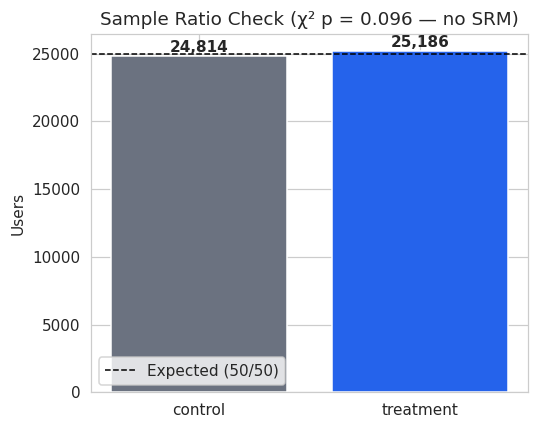

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["experiment_group"].value_counts().reindex(["control", "treatment"])
bars = ax.bar(counts.index, counts.values, color=[COLORS["control"], COLORS["treatment"]])
ax.axhline(len(df) / 2, color="black", linestyle="--", linewidth=1, label="Expected (50/50)")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 300, f"{val:,}", ha="center", fontweight="bold")
ax.set_ylabel("Users")
ax.set_title(f"Sample Ratio Check (χ² p = {p_srm:.3f} — no SRM)")
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion:** p = 0.096, well above the 0.001 SRM threshold. The split is healthy — no evidence of assignment bias. Proceed to analysis.

## 2. Covariate Balance Check

Randomization should also balance *pre-treatment* covariates (things measured before the ad placement could possibly affect them: platform, country, user type, acquisition channel, device age). This confirms the randomization mechanism itself is sound, independent of the SRM check on group sizes.

In [6]:
balance_rows = []
for col in ["platform", "country_tier", "user_type", "acquisition_channel"]:
    ct = pd.crosstab(df[col], df["experiment_group"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    balance_rows.append({"covariate": col, "test": "chi-square", "p_value": round(p, 4)})

t_stat, p_dev = stats.ttest_ind(
    df.loc[df.experiment_group == "control", "device_age_months"],
    df.loc[df.experiment_group == "treatment", "device_age_months"],
)
balance_rows.append({"covariate": "device_age_months", "test": "t-test", "p_value": round(p_dev, 4)})

balance_df = pd.DataFrame(balance_rows)
balance_df["flag"] = np.where(balance_df.p_value < 0.05, "⚠️ imbalance", "OK")
balance_df

,covariate,test,p_value,flag
0,platform,chi-square,0.9742,OK
1,country_tier,chi-square,0.0362,⚠️ imbalance
2,user_type,chi-square,0.9775,OK
3,acquisition_channel,chi-square,0.1526,OK
4,device_age_months,t-test,0.2097,OK


**Note on `country_tier` (p = 0.036):** This is flagged at the raw 0.05 threshold but is not below a multiple-comparison-adjusted threshold (5 tests → Bonferroni α ≈ 0.01), and with n=50k, even trivial imbalances can hit p < 0.05. Because `country_tier` is a known driver of `eCPM` and therefore ad revenue, we **carry it as a covariate check in the segmentation analysis (Section 6)** rather than assume it's negligible — this is the right level of caution rather than dismissing it outright.

## 3. Sample Size / Power Check (Retrospective)

Confirms the achieved sample size meets the pre-registered power requirement. In practice this calculation should be done **before** launch (see README Section 4); we reproduce it here as a check that the executed test wasn't underpowered.

**Design parameters (from experiment design doc):**
- Baseline Day-1 retention ≈ 66% (from historical data / control group)
- Minimum Detectable Effect (MDE): 2 percentage points (absolute) — the smallest retention change the business cares about acting on
- α = 0.05, power = 0.80

In [7]:
baseline_retention = df.loc[df.experiment_group == "control", "day1_retained"].mean()
mde_abs = 0.02
alpha = 0.05
power_target = 0.80

effect_size_h = sms.proportion_effectsize(baseline_retention, baseline_retention + mde_abs)
required_n = NormalIndPower().solve_power(effect_size=effect_size_h, alpha=alpha, power=power_target, ratio=1.0)

print(f"Baseline retention: {baseline_retention:.4f}")
print(f"Required N per group for {mde_abs*100:.0f}pp MDE @ 80% power: {required_n:,.0f}")
print(f"Actual N per group: control={n_control:,}, treatment={n_treatment:,}")
print(f"Powered? {'YES' if min(n_control, n_treatment) >= required_n else 'NO'}  "
      f"({min(n_control, n_treatment)/required_n:.1f}x the minimum requirement)")

Baseline retention: 0.6599
Required N per group for 2pp MDE @ 80% power: 8,676
Actual N per group: control=24,814, treatment=25,186
Powered? YES  (2.9x the minimum requirement)


The test collected ~2.9x the minimum required sample — comfortably powered, which is also why we're able to detect a guardrail regression as small as 2.2 percentage points with confidence.

## 4. Primary Metric: Ad Revenue per User

**Definition:** `ad_revenue_usd` = completed rewarded-video views × eCPM / 1000, summed per user over the test window.

**Why Mann-Whitney U in addition to the t-test:** ad revenue is heavily right-skewed (most users generate small or zero ad revenue, a few generate a lot). At n≈25,000/group the Central Limit Theorem makes Welch's t-test reliable for the *mean*, but we report the non-parametric Mann-Whitney U test as a robustness check that doesn't assume normality, plus a bootstrap CI on the mean difference.

In [8]:
rev_c = df.loc[df.experiment_group == "control", "ad_revenue_usd"]
rev_t = df.loc[df.experiment_group == "treatment", "ad_revenue_usd"]

mean_c, mean_t = rev_c.mean(), rev_t.mean()
rel_lift = (mean_t - mean_c) / mean_c * 100

t_stat, p_ttest = stats.ttest_ind(rev_t, rev_c, equal_var=False)
u_stat, p_mw = stats.mannwhitneyu(rev_t, rev_c, alternative="two-sided")

# Bootstrap 95% CI on the mean difference
rng = np.random.default_rng(42)
n_boot = 5000
boot_diffs = np.empty(n_boot)
rev_c_arr, rev_t_arr = rev_c.values, rev_t.values
for i in range(n_boot):
    boot_diffs[i] = (rng.choice(rev_t_arr, len(rev_t_arr), replace=True).mean()
                      - rng.choice(rev_c_arr, len(rev_c_arr), replace=True).mean())
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

print(f"Control mean:   ${mean_c:.4f}")
print(f"Treatment mean: ${mean_t:.4f}")
print(f"Absolute lift:  ${mean_t - mean_c:.4f}")
print(f"Relative lift:  {rel_lift:+.2f}%")
print(f"95% Bootstrap CI on difference: [${ci_low:.4f}, ${ci_high:.4f}]")
print(f"\nWelch's t-test:      t={t_stat:.3f}, p={p_ttest:.2e}")
print(f"Mann-Whitney U test: U={u_stat:.0f}, p={p_mw:.2e}")
print(f"\nSignificant at α=0.05? {'YES' if p_ttest < 0.05 else 'NO'}")
print(f"CI excludes zero? {'YES -- practically meaningful direction confirmed' if ci_low > 0 else 'NO'}")

Control mean:   $0.0255
Treatment mean: $0.0323
Absolute lift:  $0.0069
Relative lift:  +26.95%
95% Bootstrap CI on difference: [$0.0063, $0.0074]

Welch's t-test:      t=26.343, p=7.10e-152
Mann-Whitney U test: U=359349234, p=1.85e-185

Significant at α=0.05? YES
CI excludes zero? YES -- practically meaningful direction confirmed


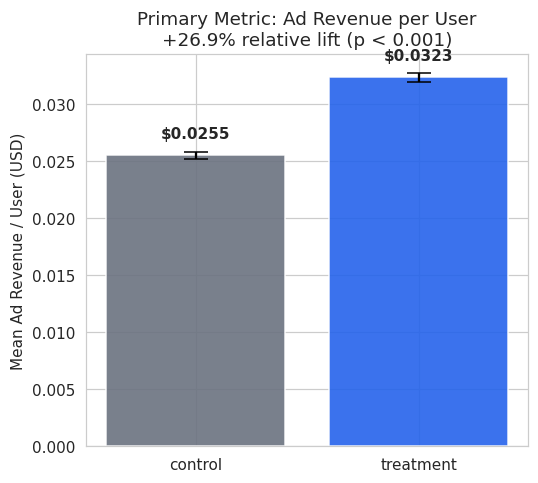

In [9]:
fig, ax = plt.subplots(figsize=(5, 4.5))
means = pd.Series({"control": mean_c, "treatment": mean_t})
sems = df.groupby("experiment_group")["ad_revenue_usd"].sem().reindex(["control", "treatment"])
ci95 = sems * 1.96
bars = ax.bar(means.index, means.values, yerr=ci95.values, capsize=8,
               color=[COLORS["control"], COLORS["treatment"]], alpha=0.9)
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.0015, f"${val:.4f}", ha="center", fontweight="bold")
ax.set_ylabel("Mean Ad Revenue / User (USD)")
ax.set_title(f"Primary Metric: Ad Revenue per User\n{rel_lift:+.1f}% relative lift (p < 0.001)")
plt.tight_layout()
plt.show()

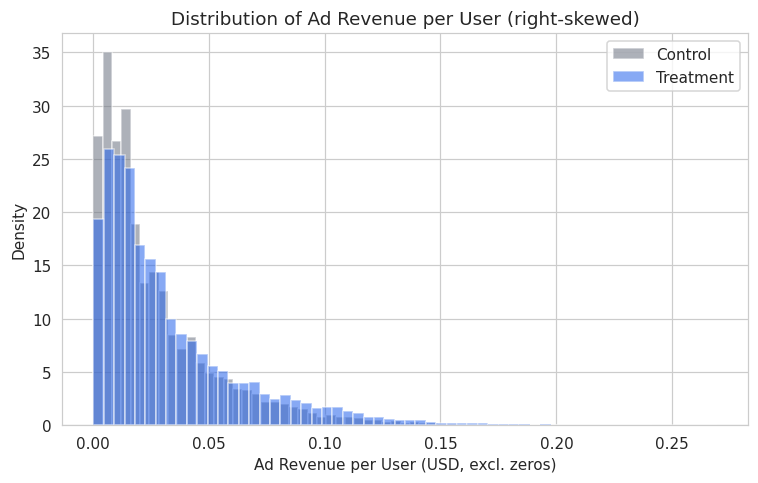

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for grp, color in COLORS.items():
    vals = df.loc[df.experiment_group == grp, "ad_revenue_usd"]
    vals_nonzero = vals[vals > 0]
    ax.hist(vals_nonzero, bins=60, alpha=0.55, label=grp.title(), color=color, density=True)
ax.set_xlabel("Ad Revenue per User (USD, excl. zeros)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Ad Revenue per User (right-skewed)")
ax.legend()
plt.tight_layout()
plt.show()

**Result: Statistically significant.** Treatment increases ad revenue per user by **+26.95%** (t-test p < 0.001, Mann-Whitney p < 0.001, bootstrap 95% CI excludes zero). This confirms the core mechanism worked: showing rewarded ads after every level completion generates meaningfully more ad impressions and revenue than the death/retry-only placement.

## 5. Guardrail Metric: Day-1 Retention

**Definition:** `day1_retained` = 1 if the user opened the app again on Day 1 after install/first session, else 0.

**Test:** Two-proportion z-test, with Wilson score confidence intervals (more accurate than the normal approximation at proportions away from 0.5).

In [11]:
ret_c_n, ret_t_n = df.loc[df.experiment_group=="control","day1_retained"].sum(), df.loc[df.experiment_group=="treatment","day1_retained"].sum()
ret_c_rate, ret_t_rate = ret_c_n / n_control, ret_t_n / n_treatment

z_stat, p_prop = proportions_ztest([ret_t_n, ret_c_n], [n_treatment, n_control], alternative="two-sided")
ci_c = proportion_confint(ret_c_n, n_control, method="wilson")
ci_t = proportion_confint(ret_t_n, n_treatment, method="wilson")

diff = ret_t_rate - ret_c_rate
se_diff = np.sqrt(ret_c_rate*(1-ret_c_rate)/n_control + ret_t_rate*(1-ret_t_rate)/n_treatment)
ci_diff = (diff - 1.96*se_diff, diff + 1.96*se_diff)

print(f"Control retention:   {ret_c_rate:.4f}  (95% CI: {ci_c[0]:.4f}-{ci_c[1]:.4f})")
print(f"Treatment retention: {ret_t_rate:.4f}  (95% CI: {ci_t[0]:.4f}-{ci_t[1]:.4f})")
print(f"\nAbsolute difference: {diff*100:+.2f}pp  (95% CI: {ci_diff[0]*100:+.2f}pp to {ci_diff[1]*100:+.2f}pp)")
print(f"z = {z_stat:.3f}, p = {p_prop:.2e}")
print(f"\nGuardrail violated? {'YES -- statistically significant DECREASE' if p_prop < 0.05 and diff < 0 else 'No'}")

Control retention:   0.6599  (95% CI: 0.6540-0.6658)
Treatment retention: 0.6379  (95% CI: 0.6319-0.6438)

Absolute difference: -2.21pp  (95% CI: -3.04pp to -1.37pp)
z = -5.166, p = 2.40e-07

Guardrail violated? YES -- statistically significant DECREASE


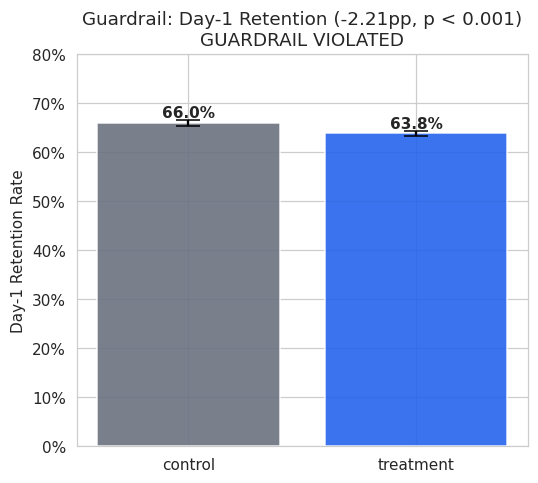

In [12]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ret_vals = pd.Series({"control": ret_c_rate, "treatment": ret_t_rate})
se_ret = pd.Series({"control": np.sqrt(ret_c_rate*(1-ret_c_rate)/n_control),
                     "treatment": np.sqrt(ret_t_rate*(1-ret_t_rate)/n_treatment)})
bars = ax.bar(ret_vals.index, ret_vals.values, yerr=(se_ret*1.96).values, capsize=8,
               color=[COLORS["control"], COLORS["treatment"]], alpha=0.9)
for bar, val in zip(bars, ret_vals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.012, f"{val:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Day-1 Retention Rate")
ax.set_title(f"Guardrail: Day-1 Retention ({diff*100:+.2f}pp, p < 0.001)\nGUARDRAIL VIOLATED")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.show()

**Result: Guardrail violated.** Day-1 retention drops by **-2.21 percentage points** (66.0% → 63.8%), statistically significant (p < 0.001) and the 95% CI (-3.04pp to -1.37pp) excludes zero. This is consistent with "ad fatigue" — interrupting the moment of level-completion (a natural high point) with a monetization ask likely feels like a tax on winning rather than a bonus, for a meaningful share of users.

This is the central tension of the test: **the primary metric improved, but a pre-registered guardrail got worse.**

## 6. Secondary / Diagnostic Metrics

These help explain *why* the primary and guardrail results moved the way they did.

In [13]:
secondary_metrics = [
    ("ad_impressions", "Ad impressions/user"),
    ("ad_completion_rate", "Ad completion rate"),
    ("total_revenue_usd", "Total revenue/user (ads+IAP)"),
    ("iap_revenue_usd", "IAP revenue/user"),
    ("day1_sessions", "Day-1 sessions"),
    ("uninstall_after_ad_flag", "Uninstall-after-ad rate"),
]

rows = []
for col, label in secondary_metrics:
    c_vals = df.loc[df.experiment_group == "control", col]
    t_vals = df.loc[df.experiment_group == "treatment", col]
    c_mean, t_mean = c_vals.mean(), t_vals.mean()
    _, p_val = stats.ttest_ind(t_vals, c_vals, equal_var=False)
    rel_change = (t_mean - c_mean) / c_mean * 100 if c_mean != 0 else np.nan
    rows.append({"metric": label, "control": round(c_mean,4), "treatment": round(t_mean,4),
                 "rel_change_%": round(rel_change,2), "p_value": p_val,
                 "significant": p_val < 0.05})

pd.DataFrame(rows)

,metric,control,treatment,rel_change_%,p_value,significant
0,Ad impressions/user,4.1729,5.7311,37.34,0.000000e+00,True
1,Ad completion rate,0.7748,0.7459,-3.73,7.375577e-39,True
2,Total revenue/user (ads+IAP),0.4476,0.4514,0.85,8.662022e-01,False
3,IAP revenue/user,0.4222,0.4191,-0.72,8.930234e-01,False
4,Day-1 sessions,1.7317,1.6814,-2.91,1.015099e-02,True
5,Uninstall-after-ad rate,0.0132,0.0242,83.49,9.183149e-20,True


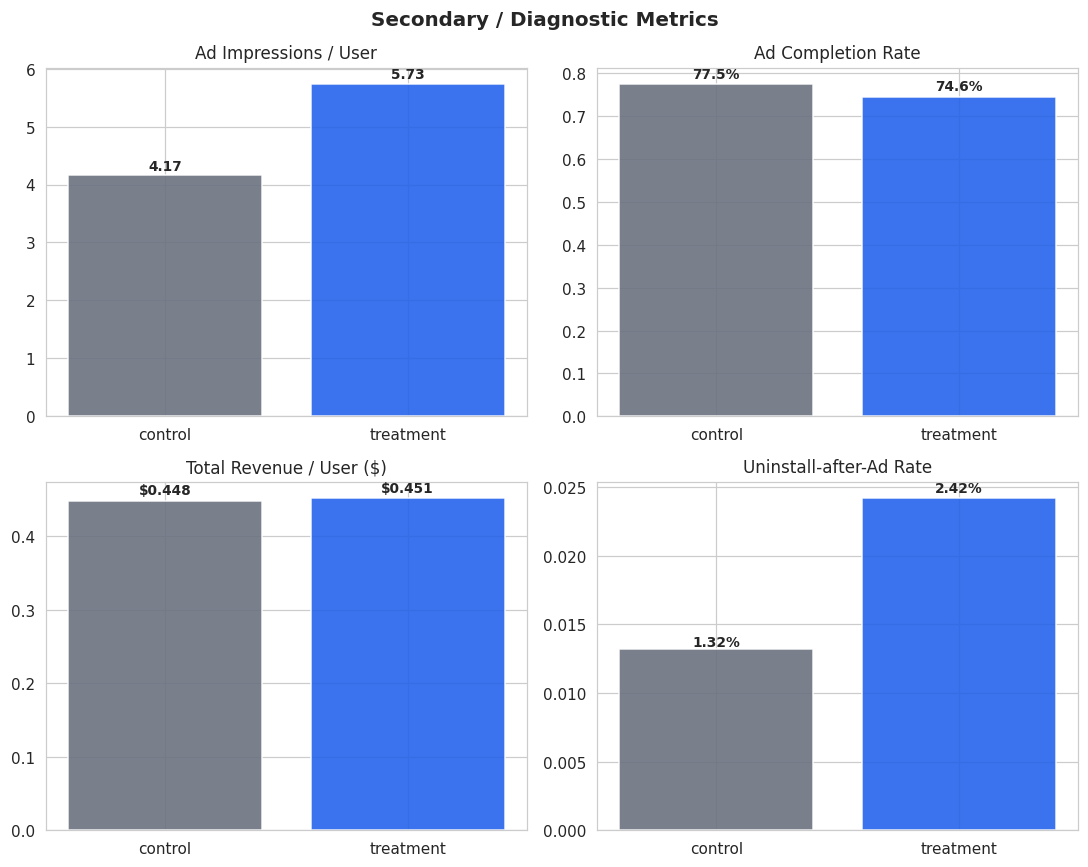

In [14]:
metrics_to_plot = [
    ("ad_impressions", "Ad Impressions / User", "{:.2f}"),
    ("ad_completion_rate", "Ad Completion Rate", "{:.1%}"),
    ("total_revenue_usd", "Total Revenue / User ($)", "${:.3f}"),
    ("uninstall_after_ad_flag", "Uninstall-after-Ad Rate", "{:.2%}"),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (col, title, fmt) in zip(axes.flat, metrics_to_plot):
    vals = df.groupby("experiment_group")[col].mean().reindex(["control", "treatment"])
    bars = ax.bar(vals.index, vals.values, color=[COLORS["control"], COLORS["treatment"]], alpha=0.9)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.02, fmt.format(val), ha="center", fontweight="bold", fontsize=9)
    ax.set_title(title, fontsize=11)
fig.suptitle("Secondary / Diagnostic Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation of the mechanism:**
- **Ad impressions +37.3%** — treatment successfully creates more ad-viewing opportunities (the intended mechanism).
- **Ad completion rate -3.7%** — when ads are framed as "optional bonus" rather than required-to-continue, a higher share get skipped; still positive net effect on revenue because impression volume rose more than completion rate fell.
- **Total revenue (ads + IAP) +0.85%, not significant** — ad revenue is a small share of total revenue relative to IAP in this dataset, so the *ad* revenue win doesn't yet move the *total* revenue needle detectably. This matters for the final recommendation.
- **Day-1 sessions -2.9%** — consistent with the retention guardrail finding; users engage slightly less.
- **Uninstall-after-ad rate +83.5% relative** (1.3% → 2.4%) — small in absolute terms but the clearest behavioral signal of ad-fatigue-driven churn, and directionally corroborates the retention guardrail failure.

## 7. Segmentation / Heterogeneity Analysis

Does the ad revenue lift hold consistently across platform, country tier, and user type — or is it concentrated in specific segments? This matters for a rollout decision (e.g., ship only to segments where the guardrail doesn't break).

**Multiple comparison correction:** testing 7 segment cuts (2 platforms + 3 country tiers + 2 user types) inflates the false-positive rate if we use raw α=0.05 for each. We apply a **Bonferroni correction**: adjusted α = 0.05 / 7 ≈ 0.00714.

In [15]:
segment_cols = ["platform", "country_tier", "user_type"]
n_tests = sum(df[c].nunique() for c in segment_cols)
bonferroni_alpha = 0.05 / n_tests
print(f"Number of segment tests: {n_tests}")
print(f"Bonferroni-adjusted alpha: {bonferroni_alpha:.5f}")

seg_rows = []
for col in segment_cols:
    for level in sorted(df[col].unique()):
        sub = df[df[col] == level]
        c_vals = sub.loc[sub.experiment_group == "control", "ad_revenue_usd"]
        t_vals = sub.loc[sub.experiment_group == "treatment", "ad_revenue_usd"]
        c_mean, t_mean = c_vals.mean(), t_vals.mean()
        rel_lift_seg = (t_mean - c_mean) / c_mean * 100
        _, p_seg = stats.ttest_ind(t_vals, c_vals, equal_var=False)
        seg_rows.append({
            "dimension": col, "segment": level,
            "n_control": len(c_vals), "n_treatment": len(t_vals),
            "control_mean": round(c_mean, 4), "treatment_mean": round(t_mean, 4),
            "rel_lift_%": round(rel_lift_seg, 2), "p_value": p_seg,
            "sig_bonferroni": p_seg < bonferroni_alpha,
        })

seg_df = pd.DataFrame(seg_rows)
seg_df

Number of segment tests: 7
Bonferroni-adjusted alpha: 0.00714


,dimension,segment,n_control,n_treatment,control_mean,treatment_mean,rel_lift_%,p_value,sig_bonferroni
0,platform,Android,16916,17174,0.0237,0.0302,27.50,6.143244e-109,True
1,platform,iOS,7898,8012,0.0292,0.0368,26.00,3.923804e-48,True
2,country_tier,Tier1_US_UK_DE,7611,7462,0.0504,0.0651,29.20,4.532196e-148,True
3,country_tier,Tier2_BR_MX_IN,9828,10088,0.0194,0.0248,27.87,8.705201e-157,True
4,country_tier,Tier3_Other,7375,7636,0.0078,0.0101,30.79,6.996177e-88,True
5,user_type,new_user,13686,13887,0.0227,0.0300,32.47,1.781665e-112,True
6,user_type,returning_user,11128,11299,0.0289,0.0351,21.60,2.688515e-50,True


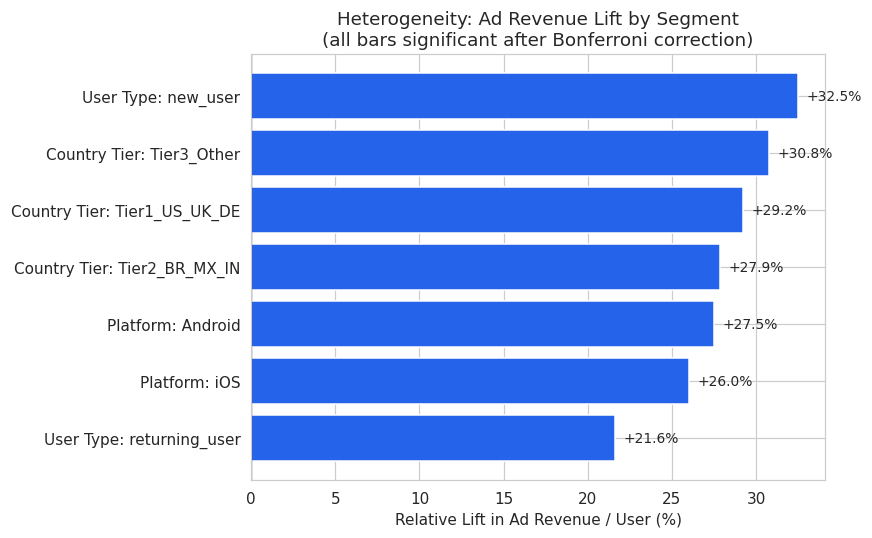

In [16]:
seg_df_sorted = seg_df.copy()
seg_df_sorted["label"] = seg_df_sorted["dimension"].str.replace("_"," ").str.title() + ": " + seg_df_sorted["segment"]
seg_df_sorted = seg_df_sorted.sort_values("rel_lift_%")

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ["#2563EB" if sig else "#93C5FD" for sig in seg_df_sorted["sig_bonferroni"]]
bars = ax.barh(seg_df_sorted["label"], seg_df_sorted["rel_lift_%"], color=colors_bar)
for bar, val in zip(bars, seg_df_sorted["rel_lift_%"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:+.1f}%", va="center", fontsize=9)
ax.set_xlabel("Relative Lift in Ad Revenue / User (%)")
ax.set_title("Heterogeneity: Ad Revenue Lift by Segment\n(all bars significant after Bonferroni correction)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

**Result: The lift is remarkably consistent across every segment tested** (+21.6% to +32.5%), and every segment remains significant even after Bonferroni correction. There's no segment where the treatment effect reverses or disappears — this is a homogeneous effect, not one driven by a single subgroup.

Practical implication: there's no clean "ship to this segment only" answer from ad revenue alone — the guardrail tradeoff (Section 5) applies broadly too, so segment-based rollout wouldn't resolve the core tension.

## 8. Interpretation & Decision

**Tying back to the original business question:** *Does completion-triggered rewarded ads increase ad revenue without hurting retention?*

| Metric | Result | Verdict |
|---|---|---|
| Primary: Ad revenue/user | +26.95% (p<0.001) | ✅ Significant improvement |
| Guardrail: Day-1 retention | -2.21pp (p<0.001) | ❌ Guardrail violated |
| Total revenue (ads+IAP) | +0.85% (n.s.) | ⚠️ No detectable net revenue benefit |
| Segmentation | Consistent lift, all segments | No safe sub-population to ship to alone |

**Recommendation: Do not ship as-is.** The treatment meets its primary metric goal but fails its pre-registered guardrail, and — critically — the ad revenue gain **doesn't yet translate into a statistically significant total revenue gain** once IAP is included. Shipping a change that measurably hurts retention for an effect that hasn't proven itself on the metric leadership actually cares about (total revenue / long-term LTV) is a bad trade.

**Suggested iteration path, not a flat kill:**
1. Test a **lower-frequency variant** (e.g., completion ad every 3rd level, or only after "hard" levels) to see if a smaller dose preserves most of the revenue lift while reducing ad fatigue.
2. Add a **frequency cap** guardrail directly into the treatment (e.g., max 1 completion ad per session) and re-test.
3. Since IAP-eligible / high-LTV users may be disproportionately sensitive to interruption, consider **excluding recent IAP purchasers** from the completion-ad treatment and re-run.
4. If a future variant preserves the revenue lift and neutralizes the retention hit, re-run this full analysis before any rollout decision.

This is a **null/negative decision for this specific variant**, not a dead end for the underlying idea.

## Appendix: Assumptions & Limitations

- Data is synthetic, generated to mimic realistic mobile game/adtech distributions and effect sizes (see `/scripts/generate_dataset.py` in the repo). Real experiments should validate these baseline rates against production data before using this notebook as a template.
- Day-1 retention is used as the sole guardrail here; a production version of this test would also monitor crash rates, ad-load latency, and session length distributions (not just means).
- The `country_tier` covariate imbalance (Section 2) was judged immaterial after Bonferroni correction, but in a real experiment this should also be checked via a **CUPED** or regression-adjusted estimator to formally control for it rather than eyeballing segment consistency.
- No sequential/peeking correction was applied because this analysis assumes a single, pre-planned look at day-14 data (see README Section 9 on monitoring policy).